## Figure 2 {q, p} phase space plot corresponding to different energy levels.

In [2]:
import utils
import functions
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import hnn
from configs import CONFIGS

config = CONFIGS["LHNN_1DGaussianmixture"]
config["acti"] = "sin"
model = hnn.HNN(config["input_dim"], config["num_hidden"], config["num_layers"], config["output_dim"], acti=config["acti"], baseline=config["baseline"], field_type=config["field_type"])
model.load_weights("/home/ycui/Documents/TSRLproject_JPMorgan/models/LHNN_1DGaussianmixture_sin.weights.h5")

initial_state = np.zeros(2)

timegrad_fn = utils.get_timegrad_fn(functions.functions("1D_Gauss_mix"))
states_numgrad, states_lhnn = [], []
for idx in range(9):
    initial_state[1] = 1/3 * (idx+1)
    states_numgrad.append(utils.get_trajectory(timegrad_fn, initial_state=initial_state, dt=0.05, num_lf=200,require_grads=False)[0])
    states_lhnn.append(utils.get_trajectory(lambda x: model.get_gradient(tf.convert_to_tensor(x.reshape(1,-1), dtype=tf.float32)).numpy().flatten(), initial_state=initial_state, dt=0.05, num_lf=100,require_grads=False)[0])


I0000 00:00:1733564582.397777   66746 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13016 MB memory:  -> device: 0, name: Tesla V100-PCIE-16GB, pci bus id: 0000:3b:00.0, compute capability: 7.0
I0000 00:00:1733564582.398498   66746 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 11758 MB memory:  -> device: 1, name: Tesla V100-PCIE-16GB, pci bus id: 0000:af:00.0, compute capability: 7.0
I0000 00:00:1733564582.399370   66746 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 4674 MB memory:  -> device: 2, name: Tesla V100-PCIE-16GB, pci bus id: 0000:d8:00.0, compute capability: 7.0


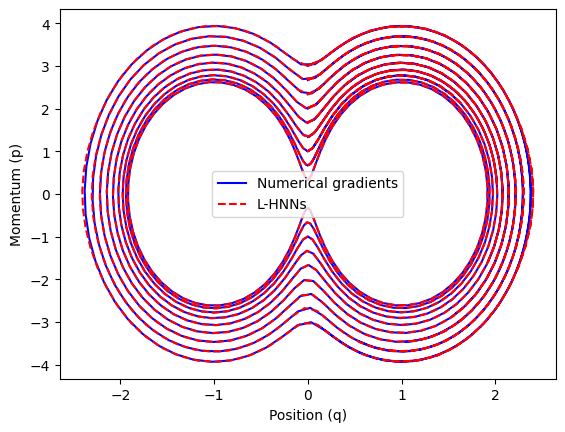

In [21]:
for idx, states in enumerate(states_numgrad):
    if idx == 0:
        plt.plot(states[:100,0], states[:100,1], color="blue", linestyle="-", label="Numerical gradients")
    else:
        plt.plot(states[:100,0], states[:100,1], color="blue", linestyle="-")
for idx, states in enumerate(states_lhnn):
    if idx == 0:
        plt.plot(states[:100,0], states[:100,1], color="red", linestyle="--", label="L-HNNs")
    else:
        plt.plot(states[:100,0], states[:100,1], color="red", linestyle="--")
plt.xlabel("Position (q)")
plt.ylabel("Momentum (p)")
plt.legend()
plt.show()

In [11]:
from sampling import sampling

hmc_lhnn_1DGaussian = sampling(config_name="LHNN_1DGaussianmixture", sampler_type="HMC", initial_state=np.array([0]), num_samples=5000, burnin=1000, chains=1, epsilon=0.05, 
                        sample_path = "/home/ycui/Documents/TSRLproject_JPMorgan/samples/lhnn_hmc_LHNN_1DGaussianmixture.pkl")
hmc_grad_1DGaussian = sampling(config_name="LHNN_1DGaussianmixture", sampler_type="HMC", initial_state=np.array([0]), num_samples=5000, burnin=1000, chains=1, epsilon=0.05, 
                        sample_path = "/home/ycui/Documents/TSRLproject_JPMorgan/samples/grad_hmc_LHNN_1DGaussianmixture.pkl")

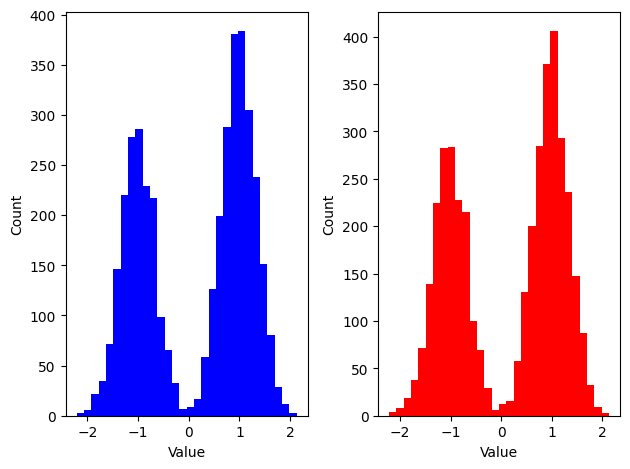

In [12]:
plt.subplot(1,2,1)
plt.hist(hmc_grad_1DGaussian.samples[:,hmc_grad_1DGaussian.burnin:,:].flatten(), color="blue", bins=30, density=False)
plt.xlabel("Value")
plt.ylabel("Count")

plt.subplot(1,2,2)
plt.hist(hmc_lhnn_1DGaussian.samples[:,hmc_lhnn_1DGaussian.burnin:,:].flatten(), color="red", bins=30, density=False)
plt.xlabel("Value")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## Figure 3

In [13]:
import utils
import functions
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import hnn
from configs import CONFIGS

config = CONFIGS["LHNN_1DGaussianmixture"]
model = hnn.HNN(config["input_dim"], config["num_hidden"], config["num_layers"], config["output_dim"], acti=config["acti"], baseline=config["baseline"], field_type=config["field_type"])
model.load_weights("/home/ycui/Documents/TSRLproject_JPMorgan/models/LHNN_1DGaussianmixture_sin.weights.h5")

initial_state = np.zeros(2)

timegrad_fn = utils.get_timegrad_fn(functions.functions("1D_Gauss_mix"))
states_lhnn = []
momentums = [2,-3]
for idx in range(2):
    initial_state[1] = momentums[idx]
    states_lhnn.append(utils.get_trajectory(lambda x: model.get_gradient(tf.convert_to_tensor(x.reshape(1,-1), dtype=tf.float32)).numpy().flatten(), initial_state=initial_state, dt=0.05, num_lf=100,require_grads=False)[0])
states_lhnn_reversed = []
for states in states_lhnn:
    initial_state = states[-1]
    initial_state[1] = -initial_state[1]
    states_lhnn_reversed.append(utils.get_trajectory(lambda x: model.get_gradient(tf.convert_to_tensor(x.reshape(1,-1), dtype=tf.float32)).numpy().flatten(), initial_state=initial_state, dt=0.05, num_lf=100,require_grads=False)[0])


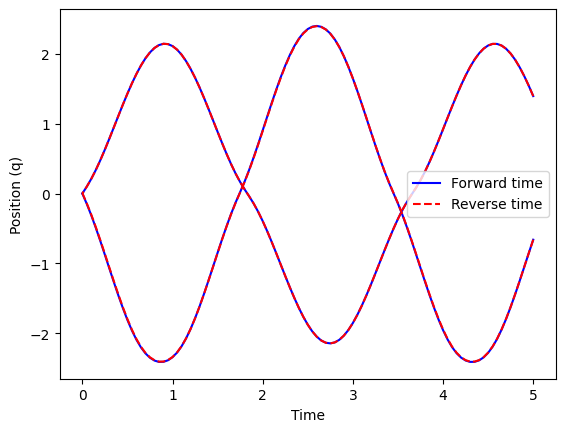

In [14]:
for idx, states in enumerate(states_lhnn):
    if idx == 0:
        plt.plot(np.linspace(0,5,101), states[:,0], color="blue", linestyle="-", label="Forward time")
    else:
        plt.plot(np.linspace(0,5,101), states[:,0], color="blue", linestyle="-")
for idx, states in enumerate(states_lhnn_reversed):
    if idx == 0:
        plt.plot(np.linspace(0,5,101)[::-1], states[:,0], color="red", linestyle="--", label="Reverse time")
    else:
        plt.plot(np.linspace(0,5,101)[::-1], states[:,0], color="red", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Position (q)")
plt.legend()
plt.show()

In [15]:
import utils
import functions
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import hnn
from configs import CONFIGS

config = CONFIGS["LHNN_1DGaussianmixture"]
config["acti"] = "sin"
model = hnn.HNN(config["input_dim"], config["num_hidden"], config["num_layers"], config["output_dim"], acti=config["acti"], baseline=config["baseline"], field_type=config["field_type"])
model.load_weights("/home/ycui/Documents/TSRLproject_JPMorgan/models/LHNN_1DGaussianmixture_sin.weights.h5")

initial_state = np.zeros(2)
H_func = functions.functions("1D_Gauss_mix")
timegrad_fn = utils.get_timegrad_fn(H_func)
states_numgrad, states_lhnn = [], []
for idx in range(10):
    initial_state[1] = 1/4 * (idx+1)
    states_numgrad.append(utils.get_trajectory(timegrad_fn, initial_state=initial_state, dt=0.05, num_lf=100,require_grads=False)[0])
    states_lhnn.append(utils.get_trajectory(lambda x: model.get_gradient(tf.convert_to_tensor(x.reshape(1,-1), dtype=tf.float32)).numpy().flatten(), initial_state=initial_state, dt=0.05, num_lf=100,require_grads=False)[0])

H_numgrad, H_lhnn = [], []
for state_n, state_l in zip(states_numgrad, states_lhnn):
    H_numgrad.append(np.array([H_func(state) for state in state_n]))
    H_lhnn.append(np.array([H_func(state) for state in state_l]))

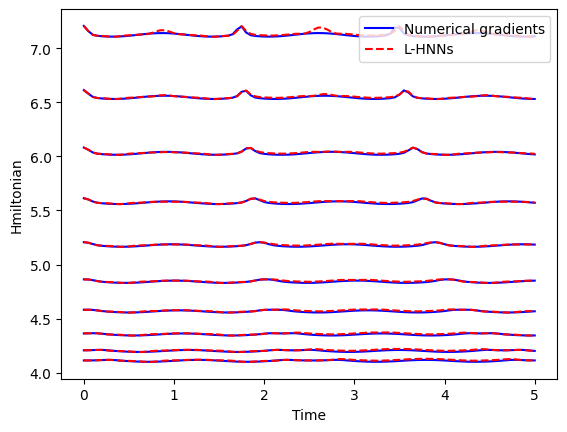

In [17]:
for idx, states in enumerate(states_numgrad):
    if idx == 0:
        plt.plot(np.linspace(0,5,101), H_numgrad[idx], color="blue", linestyle="-", label="Numerical gradients")
    else:
        plt.plot(np.linspace(0,5,101), H_numgrad[idx], color="blue", linestyle="-")
for idx, states in enumerate(states_lhnn):
    if idx == 0:
        plt.plot(np.linspace(0,5,101), H_lhnn[idx], color="red", linestyle="--", label="L-HNNs")
    else:
        plt.plot(np.linspace(0,5,101), H_lhnn[idx], color="red", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Hmiltonian")
plt.legend()
plt.show()

## Tabel 1

In [18]:
from sampling import sampling

nuts_lhnn_1DGaussian = sampling(config_name="LHNN_1DGaussianmixture", sampler_type="NUTS", initial_state=np.array([0]), num_samples=5000, burnin=1000, chains=1, epsilon=0.05, 
                                    sample_path = "/home/ycui/Documents/TSRLproject_JPMorgan/samples/lhnn_nuts_LHNN_1DGaussianmixture.pkl", threshold_nn=np.inf, threshold_lf=1000) 

nuts_grad_1DGaussian = sampling(config_name="LHNN_1DGaussianmixture", sampler_type="NUTS", initial_state=np.array([0]), num_samples=5000, burnin=1000, chains=1, epsilon=0.05, 
                                    sample_path = "/home/ycui/Documents/TSRLproject_JPMorgan/samples/grad_nuts_LHNN_1DGaussianmixture.pkl", threshold_lf=1000)


In [20]:
import pandas as pd

pd.DataFrame({"ESS per gradient of target density" : np.array([hmc_lhnn_1DGaussian.get_efficient_sample_size()[0][0] / 8000,
                                                               hmc_grad_1DGaussian.get_efficient_sample_size()[0][0] / (8000+500000),
                                                               nuts_lhnn_1DGaussian.get_efficient_sample_size()[0][0] / 8000,
                                                               nuts_grad_1DGaussian.get_efficient_sample_size()[0][0] / (8000+nuts_grad_1DGaussian.numgrad[0])])},
                index=np.array(["L-HNNs in HMC", "Traditional HMC", "L-HNNs in NUTS", "Traditional NUTS"]))

,ESS per gradient of target density
L-HNNs in HMC,0.005871
Traditional HMC,0.000093
L-HNNs in NUTS,0.004023
Traditional NUTS,0.000403


## Figure 4

In [3]:
from sampling import sampling

nuts_lhnn_3Drb_notoem = sampling(config_name="LHNN_3DRosenbrock", sampler_type="NUTS", initial_state=np.array([0,0,0]), num_samples=5000, burnin=1000, chains=1, epsilon=0.025, 
    sample_path = "/home/ycui/Documents/TSRLproject_JPMorgan/samples/lhnn_nuts_3Drb_notoem.pkl", threshold_nn=np.inf, threshold_lf=1000) # without online error monitoring.

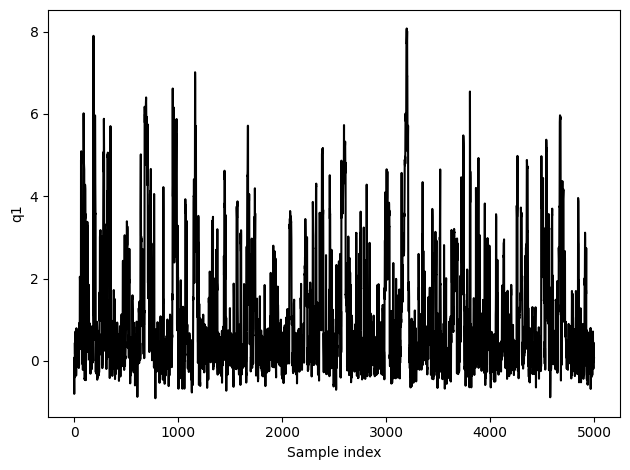

In [ ]:
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.plot(np.arange(0,5000), nuts_lhnn_3Drb_notoem.samples[0,:,i], color="black")
    plt.xlabel("Sample index")
    plt.ylabel(f"q{i+1}")
plt.tight_layout()
plt.show()


## Figure 5 and 6

In [5]:
from sampling import sampling

nuts_lhnn_3Drb = sampling(config_name="LHNN_3DRosenbrock", sampler_type="NUTS", initial_state=np.array([0,0,0]), num_samples=35000, burnin=1000, chains=1, epsilon=0.025, 
             sample_path = "/home/ycui/Documents/TSRLproject_JPMorgan/samples/lhnn_nuts_3Drb.pkl", threshold_nn=10, num_lf=20, threshold_lf=1000) # with online error monitoring.

nuts_hnn_3Drb = sampling(config_name="HNN_3DRosenbrock", sampler_type="NUTS", initial_state=np.array([0,0,0]), num_samples=35000, burnin=1000, chains=1, epsilon=0.025, 
             sample_path = "/home/ycui/Documents/TSRLproject_JPMorgan/samples/hnn_nuts_3Drb.pkl", threshold_nn=10, num_lf=20, threshold_lf=1000) # with online error monitoring.

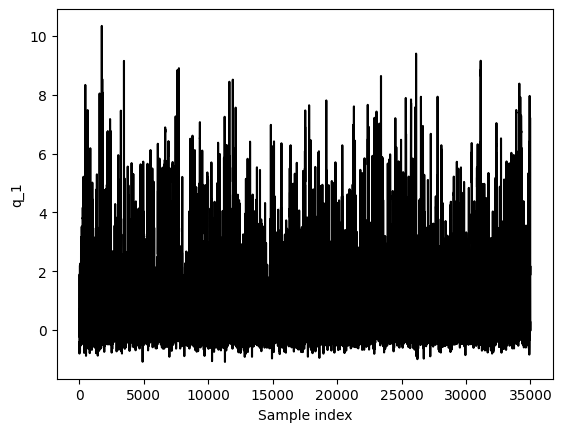

In [10]:
plt.subplot(1,1,1)
plt.plot(nuts_hnn_3Drb.samples[0,:,0], color="black")
plt.xlabel("Sample index")
plt.ylabel("q_1")

# plt.subplot(1,2,2)
# plt.plot(nuts_lhnn_3Drb.samples[0,:,0], color="red")
# plt.xlabel("Sample index")
# plt.ylabel("q_1")

# plt.tight_layout()
plt.show()

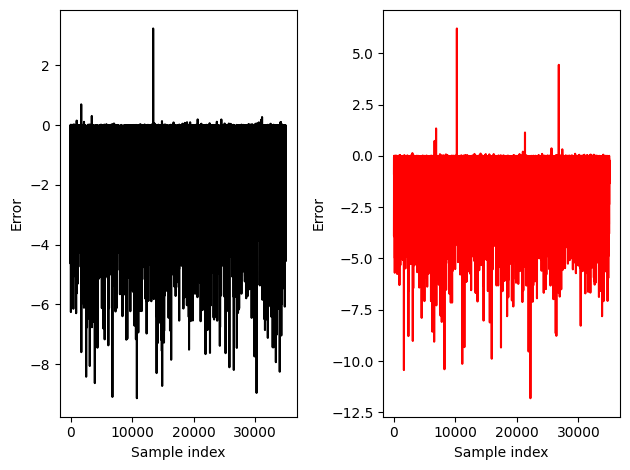

In [7]:
plt.subplot(1,2,1)
plt.plot(nuts_hnn_3Drb.monitor[0,:], color="black")
plt.xlabel("Sample index")
plt.ylabel("Error")

plt.subplot(1,2,2)
plt.plot(nuts_lhnn_3Drb.monitor[0,:], color="red")
plt.xlabel("Sample index")
plt.ylabel("Error")

plt.tight_layout()
plt.show()

## Figure 7 and Table 2

In [ ]:
import utils
import functions
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import hnn
from configs import CONFIGS
import mcmc

model_lhnn_rb_T = {}
nuts_lhnn_rb_oem_T = {}
for T in [100, 150,250]:
    config = CONFIGS[f"LHNN_3DRosenbrock_T{T}"]
    model_lhnn_rb_T[T] = hnn.HNN(config["input_dim"], config["num_hidden"], config["num_layers"], config["output_dim"], acti=config["acti"], baseline=config["baseline"], field_type=config["field_type"])
    model_lhnn_rb_T[T].load_weights(f"/home/ycui/Documents/TSRLproject_JPMorgan/models/LHNN_3DRosenbrock_T{T}_sin.weights.h5")
    nuts_lhnn_rb_oem_T[T] = mcmc.NUTS(initial_state=np.array([0,0,0]), num_samples=125000, burnin=5000, chains=1, epsilon=0.025, hamiltonain_model=model_lhnn_rb_T[T], H_function=functions.functions("nD_Rosenbrock"),seed=config["seed"], 
                        threshold_nn=10, num_lf=20, threshold_lf=1000) # Apply the online error monitoring.
    nuts_lhnn_rb_oem_T[T].sample()

nuts_rb = mcmc.NUTS(initial_state=np.array([0,0,0]), num_samples=125000, burnin=5000, chains=1, epsilon=0.025, hamiltonain_model=None, H_function=functions.functions("nD_Rosenbrock"),seed=config["seed"], 
                        threshold_lf=1000)
nuts_rb.sample()

In [ ]:
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.ecdf(nuts_rb.samples[0,nuts_rb.burnin:,i], color="blue", linestyle="-", label="NUTS")
    for color, linestyle, T in zip(["green", "black", "red"], ["--", "-.", ".-"], [100, 150,250]):
        plt.ecdf(nuts_lhnn_rb_oem_T[T].samples[0,nuts_lhnn_rb_oem_T[T].burnin:,i], color=color, linestyle=linestyle, label=f"LHNN-NUTS T={T}")
    plt.xlabel(f"q{i+1}")
    plt.ylabel("Probability")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

dft2 = pd.DataFrame({f"ESS q{i+1}" : np.array([nuts_rb.get_efficient_sample_size()[0][i],
                                               nuts_lhnn_rb_oem_T[100].get_efficient_sample_size()[0][i],
                                               nuts_lhnn_rb_oem_T[150].get_efficient_sample_size()[0][i],
                                               nuts_lhnn_rb_oem_T[250].get_efficient_sample_size()[0][i]
]) for i in range(3)}, index = np.array(["NUTS", "LHNN-NUTS T=100", "LHNN-NUTS T=150", "LHNN-NUTS T=250"]))
dft2["# of gradients of target density during Evaluation"] = np.array([nuts_rb.numgrad[0],
                                               nuts_lhnn_rb_oem_T[100].numgrad[0],
                                               nuts_lhnn_rb_oem_T[150].numgrad[0],
                                               nuts_lhnn_rb_oem_T[250].numgrad[0]])
dft2["# of gradients of target density during Training"] = np.array([0, 160000,240000,400000])
dft2["# of gradients of target density"] = dft2["# of gradients of target density during Training"] + dft2["# of gradients of target density during Evaluation"]
dft2["Avg. ESS per gradient of target density"] = dft2[[f"ESS q{i+1}" for i in range(3)]].sum(axis=1) / dft2["# of gradients of target density"]
dft2

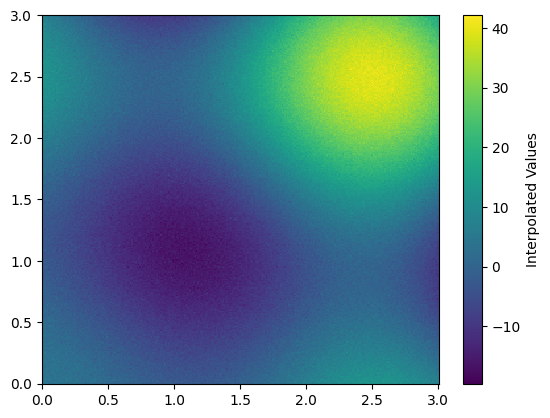

In [ ]:
import utils
_, g = utils.get_pdef()
x, y, fg = g

import matplotlib.pyplot as plt
plt.pcolormesh(x,y,fg, shading='auto', cmap='viridis')
plt.colorbar()

In [23]:
import utils

In [ ]:
H_B = 
pmgrad_fn = utils.getpmgrad_fn(H_B)


In [ ]:

utils.



In [18]:
from sampling import sampling
import numpy as np
pmhmc_lhnn_pmglmm = sampling(config_name="LHNN_pmglmm", sampler_type="PMHMC", initial_state=np.array([0]), num_samples=5000, burnin=1000, chains=1, epsilon=0.05, 
                                    sample_path = "/home/ycui/Documents/TSRLproject_JPMorgan/samples/grad_hmc_pmglmm.pkl",dim_marginal=13) 


In [9]:
pmhmc_lhnn_pmglmm.samples[0].min(axis=0)

array([ 5.83800000e-01,  3.80500000e-01, -6.37774757e+01, -3.65221672e+00,
        6.49617268e-02, -1.27629893e+01,  6.37100000e-01, -1.89852627e+01,
        0.00000000e+00, -8.41856633e-01, -5.59222202e-01, -9.12203236e+01,
       -3.15221772e+02])

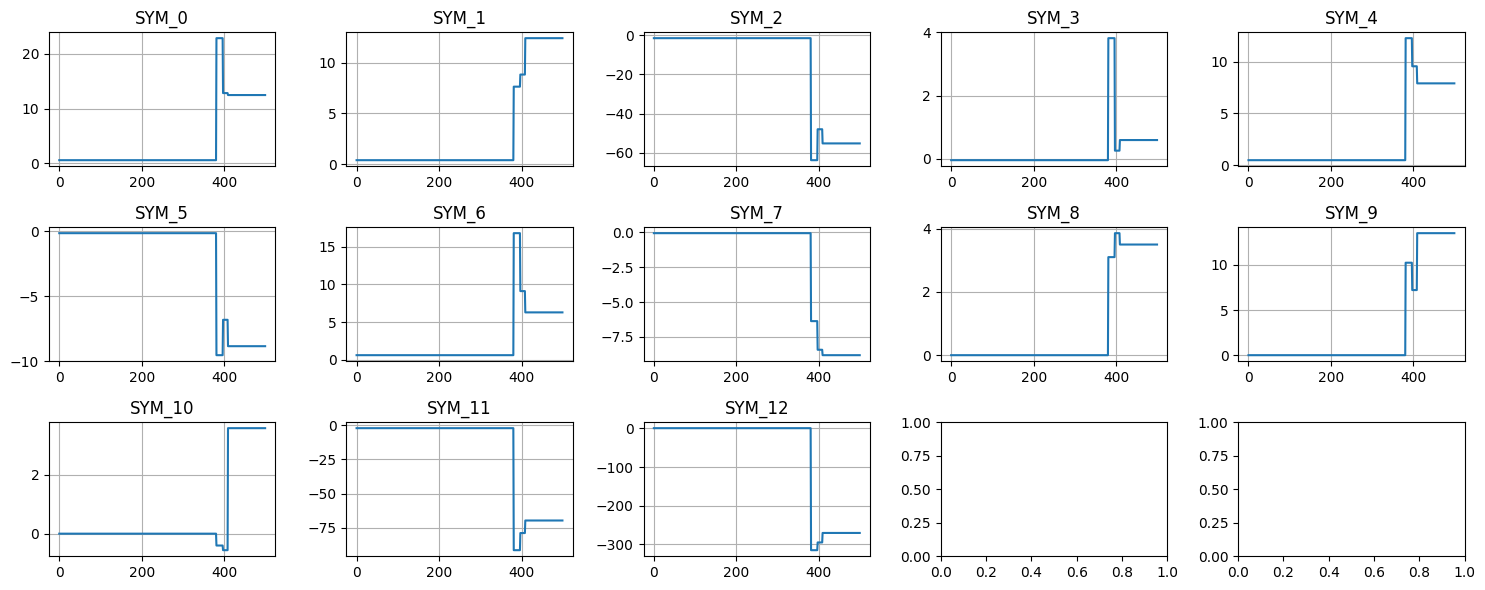

In [19]:
import numpy as np
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 5, figsize=(15, 6)) 
axes = axes.flatten()
for i in range(13):
    axes[i].plot(pmhmc_lhnn_pmglmm.samples[0][:,i])
    axes[i].set_title(f"SYM_{i}")
    axes[i].grid(True)  
plt.tight_layout()
plt.show()


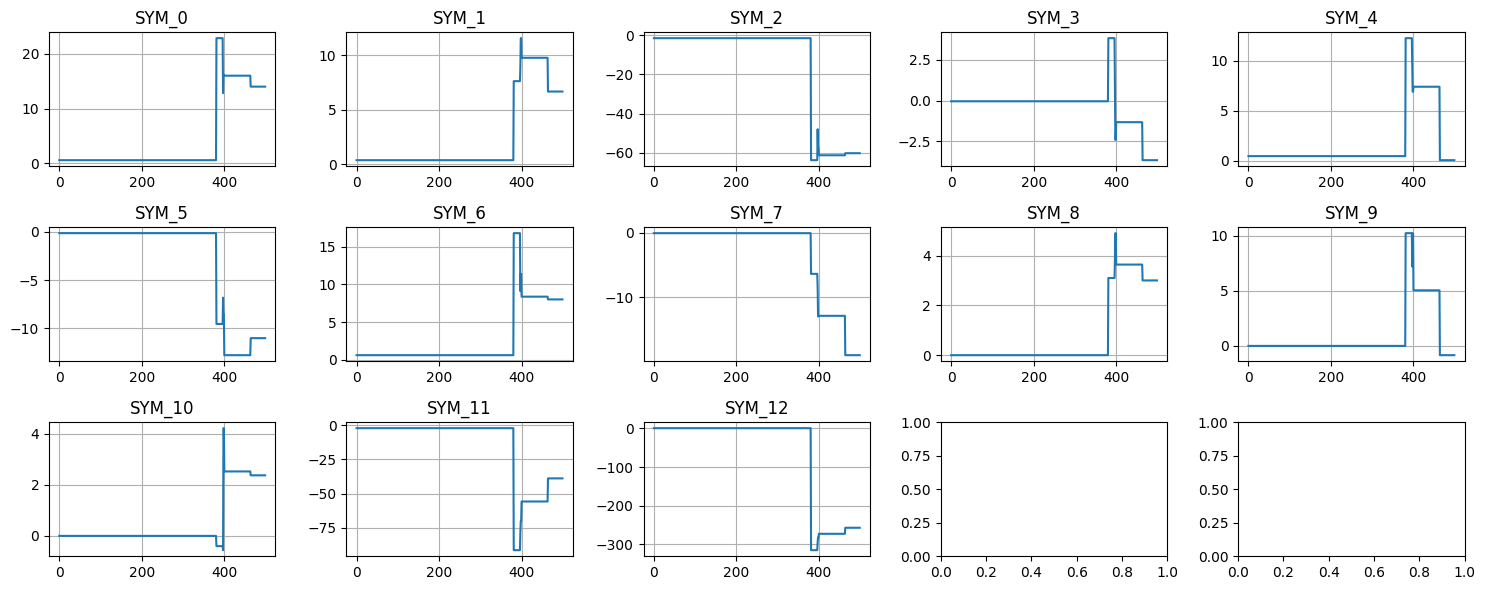

In [17]:
import numpy as np
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 5, figsize=(15, 6)) 
axes = axes.flatten()
for i in range(13):
    axes[i].plot(pmhmc_lhnn_pmglmm.samples[0][:,i])
    axes[i].set_title(f"SYM_{i}")
    axes[i].grid(True)  
plt.tight_layout()
plt.show()
